![](imagens/cabecalho_ILUM.png)

# Projeto Final de PCD — Contagem e Comparação de Open Reading Frames (ORFs) por Comprimento e GC%

**Nome:** Giovanni de Almeida Moreira (2610060)     
**Instituição:** Ilum, Escola de Ciência    

Esse projeto tem como objetivo encontrar quais são as Open Reading Frames (ORFs) presentes em sequências de DNA ou RNA, assim como sua quantidade de aminoácidos (aa) e seu percentual de nucleotídeos citosina e guanina (GC%), já que esses fatores revelam algumas características sobre elas. Ao final, compará-las através de gráficos de barra. <br>

Para fins de teste, o repositório inclui 6 sequências de organismos distintos disponíveis na pasta "sequencias", que estão detalhadas na tabela presente na seção de carregamento. O código, porém, não se limita a esses exemplos, aceita qualquer arquivo FASTA (.fna) fornecido pelo usuário, desde que ele esteja salvo na pasta anteriormente mencionada.

In [1]:
# Importação das bibliotecas
import matplotlib.pyplot as plt
from Bio import SeqIO

## 1. Carregamento das Sequências de DNA/ e ou RNA

A tabela abaixo lista as sequências de teste disponíveis na pasta "sequencias", junto de seus respectivos organismos de origem:

|Nome do Arquivo|Origem|
|:---------------:|:--------:|
|teste_DNA1.fna|*Pseudomonas putida*|
|teste_DNA2.fna|*Pseudomonas aeruginosa PAO1*|
|teste_RNA3.fna|*HIV-1 M_97CD.KTB119*|
|teste_DNA4.fna|*Acanthamoeba polyphaga mimivirus*|
|teste_DNA5.fna|*Escherichia coli O157:H7*|
|teste_DNA6.fna|*Escherichia coli str. K-12*|

*As sequências de teste utilizadas neste projeto foram obtidas no NCBI (National Center for Biotechnology Information), através do banco de dados GenBank/RefSeq.*

<br>
Ao executar a célula abaixo, o código irá pedir o nome de dois aquivos. Os nomes devem ser digitados exatamente como aparecem na tabela (incluindo a extensão `.fna`). Também é possível utilizar outros arquivos no formato FASTA, desde que eles estejam salvos na pasta "sequencias".

Como arquivos em formato FASTA costumam conter várias sequências - como em bactérias que, além do genoma, têm a sequência do plasmídeo - o código seleciona o registro de maior comprimento de cada arquivo, assumindo que ele seja o genoma. 

In [2]:
# Input que possibilita a escolha dos arquivos .fna desejados
arquivo_1 = input("Qual é o nome do arquivo onde está seu 1º genoma de interesse?")
arquivo_2 = input("Qual é o nome do arquivo onde está seu 2º genoma de interesse?")

# Define o caminho que SeqIO deve percorrer
caminho_1 = f"sequencias/{arquivo_1}"
caminho_2 = f"sequencias/{arquivo_2}"

# Atribui os registros as seus respectivos arquivos
registro_1 = list(SeqIO.parse(caminho_1, "fasta"))
registro_2 = list(SeqIO.parse(caminho_2, "fasta"))

# Seleciona o registro com maior comprimento do arquivo
genoma_1 = str(max(registro_1, key=lambda x: len(x.seq)).seq)
genoma_2 = str(max(registro_2, key=lambda x: len(x.seq)).seq)

# Tira quebras de linha para o tratamento da sequência
genoma_1 = genoma_1.replace("\n", "")
genoma_2 = genoma_2.replace("\n", "")

## 2. Identificação das ORFs

A função **`encontrar_orfs()`** faz uma busca de todas as ORFs presentes em uma sequência de DNA ou RNA, retornando um dicionário com todas as ORFs identificadas (chaves no formato `ORF_n` e valores representando a string da sequência de nucleotídeos).

Neste código, foram consideradas ORFs: regiões que começam com o *start codon* universal "AUG" (ou em DNA, "ATG") e que terminam com os *stop codons* universais "UAA", "UAG" ou "UGA" (em DNA, "TAA", "TAG" e "TGA", respectivamente). Note que essa busca é limitada por alguns motivos: essa busca não é eficiente para detectar small Open Reading Frames (sORFs), visto que muitas delas começam com *start codons* não canônicos (diferentes de "AUG"); nem consegue prever readthroughs - fenômeno que acontece principalmente em vírus, em que *stop codons* são ignorados; nem capturar ORFs provenientes de zonas com exons e introns (bastante presentes em genomas eucariotos, em que existem ORFs que têm zonas codificantes (exons) e zonas não codificantes (introns) dentro de um mesmo gene).

Além disso, o código não possui nenhum mecanismo para distinguir qual é o Read Frame que corresponderia ao gene real, ele captura ORFs de todos os Read Frames sem distinção, o que ocasiona o aumento do número total de ORFs. Outra limitação importante é o fato de o código não buscar ORFs na fita complementar, que também pode conter genes reais. Por fim, apesar de o código aceitar a entrada de símbolos ambíguos (como: R, Y, K, M, etc), ele não tem a capacidade de substituí-los ou interpretá-los como bases reais, o que afeta diretamente na contagem de ORFs, seu tamanho e possivelmente, o conteúdo GC delas.

Porém, apesar dessas limitações, o código consegue capturar uma grande quantidade delas e mostrar dados interessantes da mesma forma.

In [3]:
def encontrar_orfs(sequencia):
    """Encontra as ORFs contidas em uma sequencia de DNA ou RNA.
    
    Args:
        sequencia (str): String representando uma sequência de
            DNA ou RNA.
        
    Returns: 
        dict: Dicionário cujas chaves seguem o formato "ORF_n" 
            (onde n é um número inteiro identificando a ORF)
            e cujos valores são strings com a sequência de 
            nucleotídeos de cada ORF.
    """
    
    # =======================================================================================================================================
    # ASSERTS
    # =======================================================================================================================================

    # Garante que a entrada seja do tipo string
    assert isinstance(sequencia, str), \
        "O argumento de entrada deve ser uma string!"
    
    # Cria lista dos nucleotídeos que devem estar presentes
    # na sequência, incluindo símbolos de ambiguidade
    lista_de_simbolos = [
        "A", "T", "C", "G",
        "U", "R", "Y", "K",
        "M", "S", "W", "B",
        "D", "H", "V", "N",
    ]
    
    # Garante que a entrada seja uma sequência de DNA ou RNA
    assert all(x in lista_de_simbolos for x in sequencia), \
        """"O argumento de entrada deve ser uma sequência
        de DNA ou RNA válida!
        """

    # =======================================================================================================================================
    # CÓDIGO PRINCIPAL
    # =======================================================================================================================================

    # Transcreve a sequência de entrada
    sequencia = sequencia.replace("T", "U")

    # Cria um dicionário vazio para a adição de ORFs
    orfs = dict()
    contador = 1
    i = 0

    # Define quais são os start codons e stop codons
    START = ["AUG"]
    STOP = ["UAA", "UAG", "UGA"]

    # Percorre toda a sequência, de 3 em 3, em busca de um códon "AUG"
    # enquanto i for menor que o tamanho da sequência
    while i < len(sequencia) - 2:
        if sequencia[i:i+3] in START:
            achou_stop = False

            ## Percorre a sequência buscando stop codons
            for j in range(i, len(sequencia)-2, 3):
                codon = sequencia[j:j+3]
                if codon in STOP:

                    ### Captura o trecho entre o start codon e o stop codon
                    orf = sequencia[i:j+3]

                    ### Armazena as ORFs dentro de um dicionário
                    orfs[f"ORF_{contador}"] = orf
                    contador += 1
                    i = j + 3
                    achou_stop = True
                    break
                
            ## Previne loops infinitos
            if not achou_stop:
                    i += 1
        else:
                i += 1

    return orfs

## 3. Cálculos de Métrica das ORFs

Tendo as ORFs identificadas, é possível calcular algumas métricas que revelam aspectos importantes sobre elas. O comprimento de uma ORF, por exemplo, pode revelar sua provável função e também, distinguir se ela é um gene ou uma ORF espúria (que não é um gene real), já que ORFs que tem menos do que 100 aminoácidos tem maior chance de surgir por acaso, apesar da existência de sORFs reais. Já o conteúdo GC pode revelar a assinatura genômica do organismo e sinais de transferência horizontal, além de influenciar a distribuição esperada de comprimentos de ORFs espúrias.

A função **`conteudo_gc()`**, como o nome diz, calcula o conteúdo GC presente em uma sequência de DNA ou RNA. Já as funções **`contar_orfs_por_faixa_comprimento()`** e **`contar_orfs_por_faixa_gc()`** classificam as ORFs encontradas em intervalos de comprimento (aminoácidos) e conteúdo GC (%), respectivamente, contando quantas ORFs se encaixam em cada intervalo.

A escolha de agrupar as ORFs por faixa, ao invés de analisar cada ORF individualmente, veio da necessidade de melhor representá-las nas figuras da função **`comparar_orfs()`**, presente na seção 4, já que seria inviável representar números muito grandes de ORFs - que é o caso na maior parte dos genomas - em formato de gráficos de barras.

In [4]:
def conteudo_gc(sequencia):
    """Calcula a porcentagem de guanina (G) e citosina (C) em determinada sequência
    Args:
        sequencia (str): String contendo uma sequência de nucleotídeos.
        
    Returns:
        float: Conteúdo de G e C na sequência em forma de porcentagem, 
            arredondado a 1 casa decimal.
    """
    
    # =======================================================================================================================================
    # ASSERTS
    # =======================================================================================================================================

    # Garante que a entrada seja do tipo string
    assert isinstance(sequencia, str), \
        "O argumento de entrada deve ser uma string!"
    
    # Cria lista dos nucleotídeos que devem estar presentes
    # na sequência, incluindo símbolos de ambiguidade
    lista_de_simbolos = [
        "A", "T", "C", "G",
        "U", "R", "Y", "K",
        "M", "S", "W", "B",
        "D", "H", "V", "N",
    ]
    
    # Garante que a entrada seja uma sequência de DNA ou RNA
    assert all(x in lista_de_simbolos for x in sequencia), \
        """O argumento de entrada deve ser uma sequência de
        DNA ou RNA válida!
        """

    # =======================================================================================================================================
    # CÓDIGO PRINCIPAL
    # =======================================================================================================================================

    # Encontra o comprimento total da sequência
    comprimento_total = len(sequencia)

    # Encontra o número de nucleotídeos G + C
    gc = sequencia.count("G") + sequencia.count("C")

    # Calcula o GC%
    porcentagem = (gc * 100) / comprimento_total

    return round(porcentagem, 1)


In [5]:
def contar_orfs_por_faixa_comprimento(dict_orfs):

    """Conta quantas ORFs se encaixam em cada faixa de comprimento de aminoácidos.

    Args:
        dict_orfs (dict): Dicionário cujas chaves seguem o formato
            "ORF_n" (onde n é um número inteiro identificando a ORF)
            e cujos valores são strings com a sequência de nucleotídeos
            de cada ORF. Formato retornado por `encontrar_orfs()`.

    Returns:
        dict: Dicionário que tem como chaves intervalos de tamanhos e
            como valores a quantidade de ORFs que se encaixam em seus
            respectivos tamanhos.
    """

    # =======================================================================================================================================
    # ASSERTS
    # =======================================================================================================================================


    # Garante que o argumento de entrada seja um dicionário
    assert isinstance(dict_orfs, dict), \
        "O argumento de entrada deve ser um dicionário!"
    
    # Garante que as chaves do dicionário sigam o modelo imposto
    assert all(
        x.startswith("ORF_") and x[4:].isnumeric()
        for x in dict_orfs.keys()
    ), \
        """""As chaves desse dicionário não coincidem com o 
        modelo de entrada esperado: "ORF_n"
        """

    # Cria lista dos nucleotídeos que devem estar presentes
    # na sequência, incluindo símbolos de ambiguidade
    lista_de_simbolos = [
        "A", "T", "C", "G",
        "U", "R", "Y", "K",
        "M", "S", "W", "B",
        "D", "H", "V", "N"
    ]
    
    # Garante que a entrada seja uma sequência de DNA ou RNA válida
    assert all(
        x in lista_de_simbolos
        for y in dict_orfs.values()
        for x in y
    ), \
        """Os valores do dicionário de entrada devem ser uma 
        sequência de DNA ou RNA válida!"""

    # =======================================================================================================================================
    # CÓDIGO PRINCIPAL
    # =======================================================================================================================================

    # Cria dicionário com faixas de comprimento de aminoácidos
    dict_comprimentos = {
        "0 a 100":0, 
        "101 a 250":0, 
        "251 a 500":0, 
        "501 a 750":0, 
        "Maior que 750":0
    }
    
    for gene in dict_orfs.values():
        ## Calcula o comprimento de cada ORF
        comprimento_orf = (len(gene)-3)/3

        ## Classifica cada ORF de acordo com seu comprimento
        if comprimento_orf <= 100:
            dict_comprimentos["0 a 100"] += 1

        if comprimento_orf > 100 and comprimento_orf <= 250:
            dict_comprimentos["101 a 250"] += 1

        if comprimento_orf > 250 and comprimento_orf <= 500:
            dict_comprimentos["251 a 500"] += 1

        if comprimento_orf > 500 and comprimento_orf <= 750:
            dict_comprimentos["501 a 750"] += 1

        if comprimento_orf > 750:
            dict_comprimentos["Maior que 750"] += 1

    return dict_comprimentos

In [6]:
def contar_orfs_por_faixa_gc(dict_orfs):
    """Conta quantas ORFs se encaixam em cada faixa de conteudo GC.
    Args:
        dict_orfs (dict): Dicionário cujas chaves seguem o formato
            "ORF_n" (onde n é um número inteiro identificando a ORF)
            e cujos valores são strings com a sequência de nucleotídeos
            de cada ORF. Formato retornado por `encontrar_orfs()`.
    
    Returns:
        dict: Dicionário que tem como chaves intervalos de GC% e
            como valores a quantidade de ORFs que se encaixam em 
            suas respectivas porcentagens.
    """

    # =======================================================================================================================================
    # ASSERTS
    # =======================================================================================================================================

    # Garante que o argumento de entrada seja um dicionário
    assert isinstance(dict_orfs, dict), \
        "O argumento de entrada deve ser um dicionário!"
    
    # Garante que as chaves do dicionário sigam o modelo imposto
    assert all(
        x.startswith("ORF_") and x[4:].isnumeric()
        for x in dict_orfs.keys()
    ), \
        """As chaves desse dicionário não coincidem com o 
        modelo de entrada esperado: "ORF_n"
        """

    # Cria lista dos nucleotídeos que devem estar presentes
    # na sequência, incluindo símbolos de ambiguidade
    lista_de_simbolos = [
        "A", "T", "C", "G",
        "U", "R", "Y", "K",
        "M", "S", "W", "B",
        "D", "H", "V", "N",
    ]
    
    # Garante que a entrada seja uma sequência de DNA ou RNA válida
    assert all(
        x in lista_de_simbolos
        for y in dict_orfs.values()
        for x in y
    ), \
        """Os valores do dicionário de entrada devem ser uma 
        sequência de DNA ou RNA válida!
        """

    # =======================================================================================================================================
    # CÓDIGO PRINCIPAL
    # =======================================================================================================================================

    # Cria dicionário com faixas de GC%
    dict_gc = {
        "0 a 10%": 0,
        "10 a 20%": 0,
        "20 a 30%": 0,
        "30 a 40%": 0,
        "40 a 50%": 0,
        "50 a 60%": 0,
        "60 a 70%": 0,
        "70 a 80%": 0,
        "80 a 90%": 0,
        "90 a 100%": 0
    }

    # Classifica cada ORF de acordo com seu GC%
    for ORF, gene in dict_orfs.items():
        GC = conteudo_gc(gene)

        if GC < 10:
            dict_gc["0 a 10%"] += 1
        elif GC < 20:
            dict_gc["10 a 20%"] += 1
        elif GC < 30:
            dict_gc["20 a 30%"] += 1
        elif GC < 40:
            dict_gc["30 a 40%"] += 1
        elif GC < 50:
            dict_gc["40 a 50%"] += 1
        elif GC < 60:
            dict_gc["50 a 60%"] += 1
        elif GC < 70:
            dict_gc["60 a 70%"] += 1
        elif GC < 80:
            dict_gc["70 a 80%"] += 1
        elif GC < 90:
            dict_gc["80 a 90%"] += 1
        else:
            dict_gc["90 a 100%"] += 1

    return dict_gc

## 4. Comparação Entre as Sequências

A função a seguir **`compara_orfs()`** utiliza todas as funções descritas anteriormente para a criação de gráficos de barra a fim de comparar os dois genomas escolhidos no início do notebook. O código gera 3 figuras: "Número de ORFs por Sequência", "Distribuição de Comprimento das ORFs (aa)" e "Distribuição do Conteúdo GC das ORFs", respectivamente.

Ao executar a célula abaixo, o código irá perguntar o nome que você deseja dar para cada genoma que está sendo analisado. Note que as respostas correspondem aos nomes que serão escritos nos gráficos posteriormente.

In [7]:
def comparar_orfs(sequencia_1, sequencia_2):

    """Cria 3 gráficos que comparam quantidade, comprimento e o conteúdo 
    GC% de ORFs contidas nas sequências de entrada.
    Args:
        sequencia_1 (str): String contendo uma sequência de DNA ou RNA.
        sequencia_2 (str): String contendo uma sequência de DNA ou RNA.

    Returns:
        None: A função não retorna nenhum valor; ela exibe os três
            gráficos diretamente na tela.
    """

    # =======================================================================================================================================
    # ASSERTS
    # =======================================================================================================================================

    # Garante que os argumentos de entrada sejam strings
    assert isinstance(sequencia_1, str) and isinstance(sequencia_2, str), \
        "Ambos os argumentos de entrada devem ser do tipo string!"

    # Cria lista dos nucleotídeos que devem estar presentes
    # na sequência, incluindo símbolos de ambiguidade
    lista_de_simbolos = [
        "A", "T", "C", "G",
        "U", "R", "Y", "K",
        "M", "S", "W", "B",
        "D", "H", "V", "N"
    ]
    
    # Garante que as entradas sejam sequências de DNA ou RNA válidas
    assert all(
        x1 in lista_de_simbolos
        for y1 in sequencia_1
        for x1 in y1
    ), \
        """O argumento de entrada da sequencia_1 deve ser
        uma sequência de DNA ou RNA válida!
        """

    assert all(
        x2 in lista_de_simbolos
        for y2 in sequencia_2
        for x2 in y2
    ), \
        """O argumento de entrada da sequencia_2 deve ser
        uma sequência de DNA ou RNA válida!
        """

    # =======================================================================================================================================
    # CÓDIGO PRINCIPAL
    # =======================================================================================================================================
   
    # Transcreve as sequencias de DNA em RNA
    nome_sequencia1 = input("Qual nome você deseja dar a sequência 1?")
    nome_sequencia2 = input("Qual nome você deseja dar a sequência 2?")

    # Encontra os ORFs que cada sequência possui
    dict_orfs1 = encontrar_orfs(sequencia_1)
    dict_orfs2 = encontrar_orfs(sequencia_2)

    # Define os subplots pra figura 1: Número de ORFs por Sequência
    fig1, x1 = plt.subplots()

    ## Cria duas listas que são o x e o y do gráfico, sequencias e numero_de_orfs, respectivamente
    sequencias = [nome_sequencia1, nome_sequencia2]
    numero_de_orfs = [len(dict_orfs1), len(dict_orfs2)]
    
    ## Plota o gráfico da fig. 1
    x1.bar(
        sequencias, 
        numero_de_orfs,
        color=("#4059AD", "#F4B942"),
        hatch=(".", "\\\\")
    )

    ## Adiciona título, legendas e grid horizontal
    x1.set_title("Fig 1.: Número de ORFs por Sequência")

    x1.bar_label(x1.containers[0])
    x1.set_ylabel("Número de ORFs")
    x1.grid(axis="y", alpha=0.3)

    x1.set_axisbelow(True)
    
    # Define os subplots e título para figura 2: Distribuição do Comprimento das ORFs(aa)
    fig2, (x2_1, x2_2) = plt.subplots(
        1, 
        2, 
        figsize=(15, 6), 
        sharey=True,
    )
    fig2.suptitle("Fig 2.: Distribuição do Comprimento das ORFs(aa)", fontsize=18)

    ## Cria dois dicionários que contém as ORFs classificadas por comprimento
    comprimento_orfs1 = contar_orfs_por_faixa_comprimento(dict_orfs1)
    comprimento_orfs2 = contar_orfs_por_faixa_comprimento(dict_orfs2)

    ## Plota o gráfico (A) da fig 2.
    x2_1.bar(
        comprimento_orfs1.keys(), 
        comprimento_orfs1.values(), 
        color="#4059AD", 
        hatch=".",
        label=f"Número Total de ORFs: {numero_de_orfs[0]}"
    )

    ### Adiciona título, legendas e grid horizontal
    x2_1.set_title(f"(A) {nome_sequencia1}")

    x2_1.set_ylabel("Número de ORFs")
    x2_1.set_xlabel("Comprimento (aa)")
    x2_1_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[0]:.0f}%)"
        for valor in comprimento_orfs1.values()
    ]
    x2_1.bar_label(x2_1.containers[0], labels=x2_1_labels, fontsize="small")
    x2_1.legend()

    x2_1.grid(axis="y", alpha=0.3)
    x2_1.set_axisbelow(True)

    ## Plota o gráfico (B) da fig.2
    x2_2.bar(
        comprimento_orfs2.keys(), 
        comprimento_orfs2.values(), 
        color="#F4B942", 
        hatch="\\\\",
        label=f"Número Total de ORFs: {numero_de_orfs[1]}"
    )
    ### Adiciona título, legendas e grid horizontal
    x2_2.set_title(f"(B) {nome_sequencia2}")

    x2_2_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[1]:.0f}%)"
        for valor in comprimento_orfs2.values()
    ]
    x2_2.bar_label(x2_2.containers[0], labels=x2_2_labels, fontsize="small")
    x2_2.set_xlabel("Comprimento (aa)") 

    x2_2.grid(axis="y", alpha=0.3)
    x2_2.set_axisbelow(True)
    x2_2.legend()
    
    ## Adequa o tamanho da fig. 2
    fig2.tight_layout()

    # Define os subplots e título para figura 3: Distribuição do Conteúdo GC das ORFs
    fig3, (x3_1, x3_2) = plt.subplots(
        1, 
        2, 
        figsize=(15, 6), 
        sharey=True,
    )
    fig3.suptitle("Fig. 3: Distribuição do Conteúdo GC das ORFs", fontsize=18)
    
    ## Cria variáveis que armazenam o GC% global de suas respectivas sequências 
    gc_sequencia1 = conteudo_gc(sequencia_1)
    gc_sequencia2 = conteudo_gc(sequencia_2)

    ## Cria dois dicionário que contém as ORFs classficadas por GC%
    gc_dict_orfs1 = contar_orfs_por_faixa_gc(dict_orfs1)
    gc_dict_orfs2 = contar_orfs_por_faixa_gc(dict_orfs2)

    ## Plota o gráfico (A) da fig. 3
    x3_1.bar(
        gc_dict_orfs1.keys(), 
        gc_dict_orfs1.values(), 
        color="#4059AD", 
        hatch=".", 
        label=f"GC global: {gc_sequencia1}%"
    )

    ### Adiciona título, legendas e grid horizontal
    x3_1.set_title(f"(A) {nome_sequencia1}")

    x3_1_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[0]:.0f}%)"
        for valor in gc_dict_orfs1.values()
    ]
    x3_1.bar_label(x3_1.containers[0], labels=x3_1_labels, fontsize="small")
    x3_1.tick_params(axis="x", rotation=30)
    
    x3_1.set_ylabel("Número de ORFs")
    x3_1.set_xlabel("Conteúdo GC(%)")
    x3_1.legend()

    x3_1.grid(axis="y", alpha=0.3)
    x3_1.set_axisbelow(True)
    
    ## Plota o gráfico (B) da fig. 3
    x3_2.bar(
        gc_dict_orfs2.keys(), 
        gc_dict_orfs2.values(), 
        color="#F4B942", 
        hatch="\\\\",
        label=f"GC global: {gc_sequencia2}%"
    )

    ### Adiciona título, legendas e grid horizontal
    x3_2.set_title(f"(B) {nome_sequencia2}")

    x3_2_labels = [
        f"{valor} ({100 * valor / numero_de_orfs[1]:.0f}%)"
        for valor in gc_dict_orfs2.values()
    ]
    x3_2.bar_label(x3_2.containers[0], labels=x3_2_labels, fontsize="small")
    x3_2.tick_params(axis="x", rotation=30)
    x3_2.set_xlabel("Conteúdo GC(%)")
    x3_2.legend()

    x3_2.grid(axis="y", alpha=0.3)
    x3_2.set_axisbelow(True)
    
    ## Adequa o tamanho da figura
    fig3.tight_layout()
    
    return plt.show()

## 5. Conclusão

A célula abaixo utiliza a função **`comparar_orfs()`** com os dois genomas escolhidos no ínicio do código. Note que, por padrão, os genomas escolhidos para a entrega do projeto foram dos organismos Pseudomonas putida e Pseudomonas aeruginosa PAO1, respectivamente.

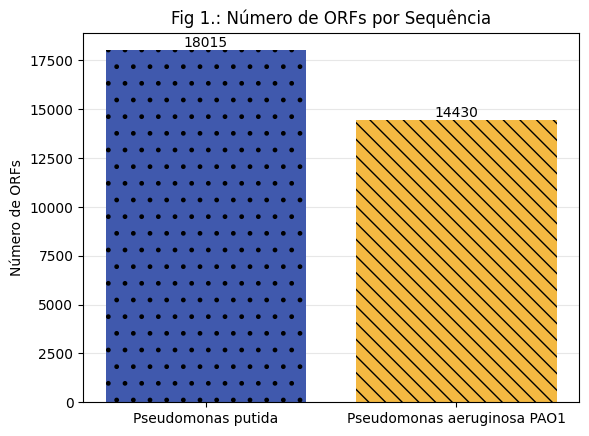

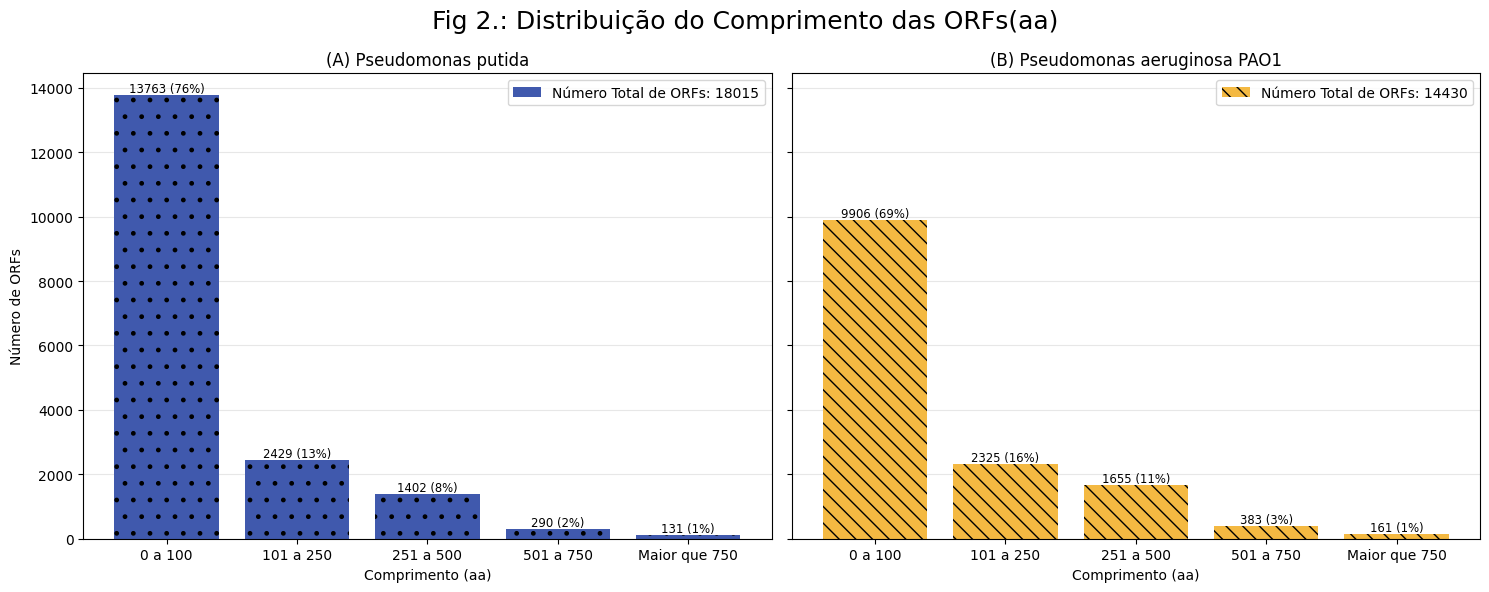

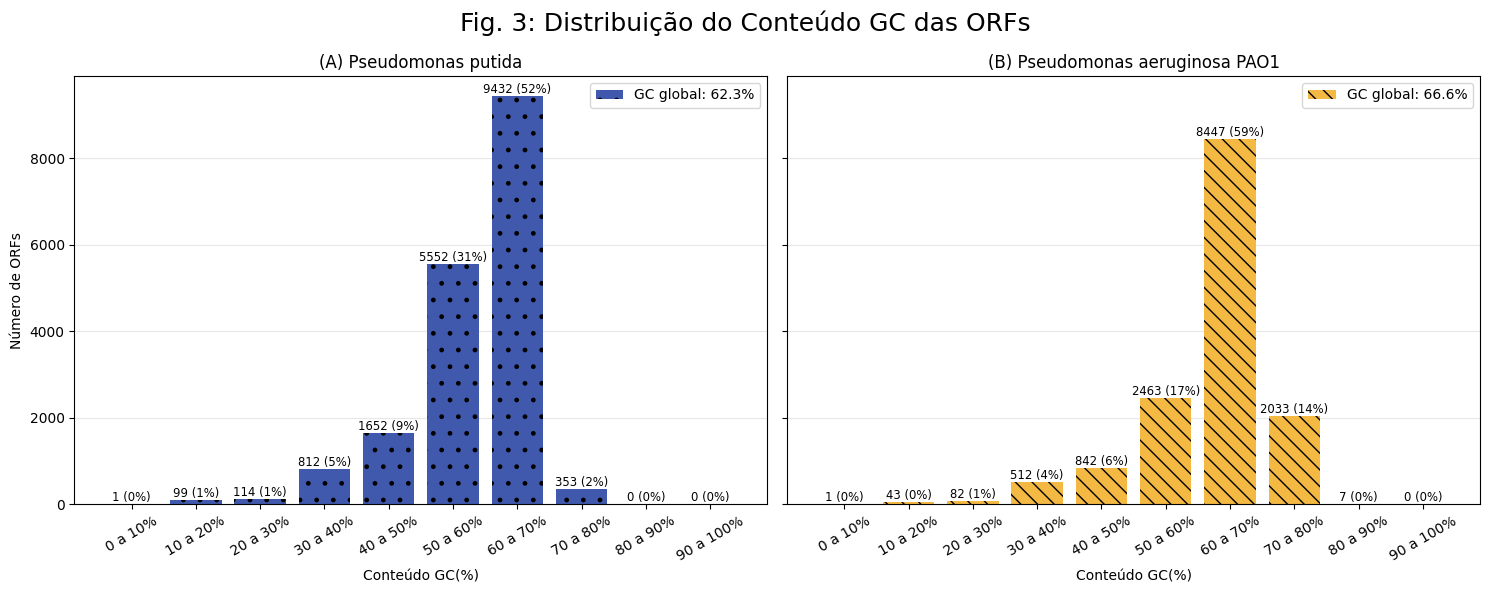

In [8]:
comparar_orfs(genoma_1, genoma_2)

Nesta execução para entrega do notebook, foram comparados os genomas de *Pseudomonas putida* e *Pseudomonas aeruginosa* PAO1. Como é mostrado na *Figura 1*, a primeira apresentou um número maior de ORFs (18.015 contra 14.430), porém mostrou conteúdo GC global mais baixo (62,3% contra 66,6%)(*Figura 3*). Em relação ao comprimento (nº de aminoácidos) das ORFs, os gráficos A e B da *Figura 2* mostram que: *P. putida* apresenta 76% e *P. aeruginosa* apresenta 69% de ORFs na faixa de comprimento de 0 a 100 aa, tornando possível supor que mesmo que *P. putida* tenha maior quantidade de ORFs, possivelmente boa parte delas - pelo fato de se enquadrarem na faixa de comprimento de 0 a 100 aa - são ORFs espúrias, pois, apesar da existência de sORFs que codificam genes reais, elas não representam uma porcentagem significativa dentro das sORFs encontradas em genes no caso das bactérias. Vale ressalvar que, em etapas prévias do desenvolvimento, o código da função **`encontrar_orfs()`** capturava um número ainda maior de ORFs, pois lia e armazenava muitas ORFs sobrepostas. Com uma mudança na lógica através da adição de um laço de repetição "while", foi possível diminuir consideravelmente esse número. Tomando como exemplo o genoma da *P. aeruginosa*, o total de ORFs encontradas caiu de aproximadamente 70.000 para 14.430 - valor que apesar de ainda estar um pouco longe do que diz a literatura, já é um dado bem mais plausível biologicamente.

Apesar de ter algumas de suas falhas corrigidas, o código ainda apresenta um número expressivo de limitações por conta de sua metodologia simples, principalmente ao ser posto em comparação com ferramentas profissionais de predição gênica que utilizam modelos estátisticos treinados, dentre outras tecnologias e técnicas que fogem do escopo deste projeto. Dentre algumas de suas limitações, o algoritmo não distingue qual dos três quadros de leitura corresponde ao gene real; não busca ORFs na fita complementar; não detecta *start codons* não canônicos e nem readthrough de *stop codons* (sendo os dois últimos citados importantes para a captura de sORFs em genomas virais); não captura ORFs corretamente em genomas com exons e introns, e não trabalha estatisticamente para realizar a predição de nucleotídeos de símbolos ambíguos. Note que essas limitações, além de mostrar o que o código é incapaz de fazer, são possíveis melhorias que poderiam ser incorporadas no futuro, a fim de obter uma melhor estimativa do número de ORFs, seu comprimento, conteúdo GC e até a possibilidade da criação de figuras que mostram outras métricas tão importantes (ou mais) do que as que foram utilizadas.

Mesmo apresentando essas limitações, o código entrega resultados interessantes e figuras que possibilitam a suposição de alguns aspectos biológicos dos genomas analisados, como foi feito no primeiro parágrafo deste texto.

Por fim, vale lembrar que esse código, embora a conclusão discuta a comparação dos genomas de bactérias do gênero *Pseudomonas*, aceita como entrada para a função **`comparar_orfs()`** qualquer um dos genomas listados na seção 1 (como as cepas de *E. coli* ou os genomas virais de **HIV-1** e **A. polyphaga mimivirus**) ou qualquer outro genoma que o usuário queira testar, desde que ele esteja no formato FASTA (.fna) e dentro da pasta "sequencias". Assim como qualquer uma das funções pode ser usada individualmente, desde que seus pré-requisitos de entrada sejam respeitados. 

## Nota sobre o uso de IA

Durante a formulação deste projeto, foram utilizadas ferramentas de Inteligência Artificial generativa: Claude (Anthropic) e Copilot (Microsoft) em conjunto para: compreensão e utilização das bibliotecas matplotlib e Biopython; revisão de estilo do código e gramática nas células de Markdown; confirmação e discussão das interpretações biológicas relacionadas a ORFs, comprimento e conteúdo GC, com base na literatura estudada (posteriormente referenciada na seção "Referências") e apoio na identificação e correção de erros na lógica dos códigos durante o desenvolvimento. Porém, a programação dos códigos, os textos finais e as conclusões científicas são de autoria própria.

## Referências

BROWN, Terence A. Understanding a genome sequence. In: **Genomes. 2nd edition.** Wiley-Liss, 2002.

CAMPBELL, Neil A. et al. Do gene à proteína. In: **Biologia. 10. ed.** Porto Alegre: Artmed, 2015.

NATIONAL CENTER FOR BIOTECHNOLOGY INFORMATION (NCBI). Bethesda: **National Library of Medicine (US)**. 
Disponível em: https://www.ncbi.nlm.nih.gov/. Acesso em: 21/06/2026.

RAVENHALL, Matt et al. Inferring horizontal gene transfer. **PLoS computational biology**, v. 11, n. 5, p. e1004095, 2015.

ZVELEBIL, Marketa J.; BAUM, Jeremy O. Genome characteristics. In: **Understanding Bioinformatics**. New York: Garland Science, 2008.

![](imagens\rodape_ILUM.png)